###import libraries

In [0]:

#Pandas is a pytrhon library for data analytics
import pandas as pd

#Numpy is a pytrhon library for arithmetic calculations/ numerical analysis
import numpy as np


#data prep
import sklearn
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn import metrics 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

#evaluation matric
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve,auc,roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn import linear_model

from sklearn.model_selection import GridSearchCV





###Data ingestion

In [0]:
data_path = '/Workspace/Users/waynendlovu16@gmail.com/Patient Readdmission analysis/Patient_Readmission_Data_Set - Expanded_Patient_Readmission_Data (1) (2).csv'



In [0]:
##to read the data from csv to pandas dataframe 
df=pd.read_csv(data_path)


In [0]:
df.head(10)
##function that helps us t see the first 10 rows of the data

,Patient ID,Age,Gender,Admission Type,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Readmission
0,1,62,Female,Elective,4,5,110,130,1,No
1,2,65,Male,Emergency,19,2,157,81,4,No
2,3,82,Female,Emergency,18,4,74,84,0,No
3,4,85,Male,Emergency,2,4,106,85,4,No
4,5,85,Female,Elective,19,3,80,119,3,No
5,6,27,Male,Emergency,18,6,136,99,2,No
6,7,39,Male,Elective,21,3,116,74,0,Yes
7,8,54,Male,Emergency,3,4,136,68,3,No
8,9,88,Female,Elective,6,6,120,81,2,No
9,10,30,Male,Elective,6,8,139,106,3,No


In [0]:
df.shape

(3000, 10)

In [0]:
df.dtypes


Patient ID              int64
Age                     int64
Gender                 object
Admission Type         object
Length of Stay          int64
Number of Diagnoses     int64
Blood Pressure          int64
Blood Sugar Levels      int64
Previous Admissions     int64
Readmission            object
dtype: object

In [0]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Admission Type', 'Length of Stay',
       'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels',
       'Previous Admissions', 'Readmission'],
      dtype='object')

###Observation
- categorical  columns :Gender ,Admission type , Readmission
Nunerical colums : PatientID , 'Age', 'Length of stay ' , 'Number of diagnoses', Blood Pressure ' ,' Blood sugar levels ', 'Previous Admission'


In [0]:
#Help us select categorical column using its data type -- datatype is an object 

print("Categorical Columns :" , list(df.select_dtypes(include=['object']).columns))

Categorical Columns : ['Gender', 'Admission Type', 'Readmission']


In [0]:

#Help us select  NUMERIACLA column using its data type -- datatype is an  INTEGER

print("Numerical Columns :" , list(df.select_dtypes(include=['int64']).columns))


Numerical Columns : ['Patient ID', 'Age', 'Length of Stay', 'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels', 'Previous Admissions']


####STEP 2 :Check data quality


In [0]:
#Count the number of duplicated rows that are duplicated in your data
df.duplicated().sum()

np.int64(0)

In [0]:
#checking number of null values in our dataset
df.isnull().sum()


Patient ID             0
Age                    0
Gender                 0
Admission Type         0
Length of Stay         0
Number of Diagnoses    0
Blood Pressure         0
Blood Sugar Levels     0
Previous Admissions    0
Readmission            0
dtype: int64

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient ID           3000 non-null   int64 
 1   Age                  3000 non-null   int64 
 2   Gender               3000 non-null   object
 3   Admission Type       3000 non-null   object
 4   Length of Stay       3000 non-null   int64 
 5   Number of Diagnoses  3000 non-null   int64 
 6   Blood Pressure       3000 non-null   int64 
 7   Blood Sugar Levels   3000 non-null   int64 
 8   Previous Admissions  3000 non-null   int64 
 9   Readmission          3000 non-null   object
dtypes: int64(7), object(3)
memory usage: 234.5+ KB


In [0]:
###visual inspection for checking impossible values

display(df)


Patient ID,Age,Gender,Admission Type,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Readmission
1,62,Female,Elective,4,5,110,130,1,No
2,65,Male,Emergency,19,2,157,81,4,No
3,82,Female,Emergency,18,4,74,84,0,No
4,85,Male,Emergency,2,4,106,85,4,No
5,85,Female,Elective,19,3,80,119,3,No
6,27,Male,Emergency,18,6,136,99,2,No
7,39,Male,Elective,21,3,116,74,0,Yes
8,54,Male,Emergency,3,4,136,68,3,No
9,88,Female,Elective,6,6,120,81,2,No
10,30,Male,Elective,6,8,139,106,3,No


In [0]:
##Check if there are any negative values in the 'age' column
# Assume your DataFrame is called df and the column is 'age'

negative_mask = df['Age'] < 0

if negative_mask.any():
    # Show rows where age is negative
    negative_rows = df[negative_mask]
    print("Rows with negative ages:")
    print(negative_rows)
else:
    print("No rows in the 'age' column have negative values.")


No rows in the 'age' column have negative values.


### STEP 3: Describe each column

###Describe numerical columns

In [0]:
df.describe()

,Patient ID,Age,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,53.453000,15.226333,4.956667,119.058000,133.536000,1.958333
std,866.169729,20.892996,8.264858,2.575073,34.089265,37.626311,1.401637
min,1.000000,18.000000,1.000000,1.000000,60.000000,51.000000,0.000000
25%,750.750000,35.000000,8.000000,3.000000,89.750000,101.000000,1.000000
50%,1500.500000,53.000000,15.000000,5.000000,119.000000,133.000000,2.000000
75%,2250.250000,72.000000,22.000000,7.000000,147.250000,167.000000,3.000000
max,3000.000000,89.000000,29.000000,9.000000,179.000000,199.000000,4.000000


###Describe categorical column

In [0]:
###Checking the unique values in the 'Readmission' column
print(df['Readmission'].unique())
print(df['Gender'].unique())
print(df['Admission Type'].unique())

['No' 'Yes']
['Female' 'Male']
['Elective' 'Emergency']


In [0]:
##This gives us the number(count) of UNIQUE VALUES / different  values in the readmission
print(df['Readmission'].nunique())
print(df['Gender'].nunique())
print(df['Admission Type'].nunique())

2
2
2


In [0]:
#Gives us the number of different values in the readmission column
df['Readmission'].value_counts()


Readmission
No     2134
Yes     866
Name: count, dtype: int64

In [0]:
#Gives us the number of different values in the Gender column
df['Gender'].value_counts()

Gender
Male      1555
Female    1445
Name: count, dtype: int64

In [0]:
#Gives us the number of different values in the admission Type column
df['Admission Type'].value_counts()

Admission Type
Elective     1563
Emergency    1437
Name: count, dtype: int64

### Step 4: Visualize Single Variables


######Univariate analysis


In [0]:

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 


In [0]:

gender_counts = df['Gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count ']

fig = px.bar(gender_counts , x='Gender', y='Count ', color='Gender', title='Gender Distribution')
fig.show()

In [0]:


fig = px.histogram(df, x='Readmission', title='Readmission Distribution')
fig.show()

In [0]:
fig = px.pie(
    df,
    names='Admission Type',
    title='admission'
)
fig.show()

##Step 5 : Explore relationships between variables (Bivariate/multivariate Analysis)

In [0]:
df.head(3)

,Patient ID,Age,Gender,Admission Type,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Readmission
0,1,62,Female,Elective,4,5,110,130,1,No
1,2,65,Male,Emergency,19,2,157,81,4,No
2,3,82,Female,Emergency,18,4,74,84,0,No


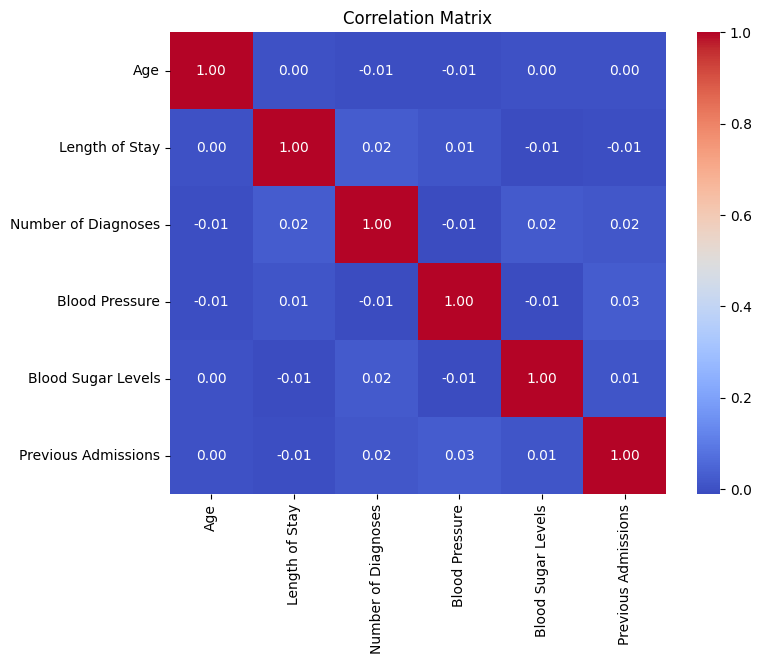

In [0]:
import seaborn as sns 
import matplotlib.pyplot as plt

cols = ['Age', 'Length of Stay', 'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels', 'Previous Admissions']
corr_matrix = df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

###Feature Engineering

####Encoding our categorical column

In [0]:
from sklearn.preprocessing import OneHotEncoder

In [0]:
categorical_columns =df.select_dtypes(include= ['object']).columns
ohe = OneHotEncoder(handle_unknown='ignore')
encoded_data = ohe.fit_transform(df[categorical_columns]).toarray()
feature_names = ohe.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(encoded_data, columns=feature_names)
df_encoded = pd.concat([df.drop(columns=categorical_columns, axis=1), encoded_df], axis=1)
display(df_encoded)


Patient ID,Age,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Gender_Female,Gender_Male,Admission Type_Elective,Admission Type_Emergency,Readmission_No,Readmission_Yes
1,62,4,5,110,130,1,1.0,0.0,1.0,0.0,1.0,0.0
2,65,19,2,157,81,4,0.0,1.0,0.0,1.0,1.0,0.0
3,82,18,4,74,84,0,1.0,0.0,0.0,1.0,1.0,0.0
4,85,2,4,106,85,4,0.0,1.0,0.0,1.0,1.0,0.0
5,85,19,3,80,119,3,1.0,0.0,1.0,0.0,1.0,0.0
6,27,18,6,136,99,2,0.0,1.0,0.0,1.0,1.0,0.0
7,39,21,3,116,74,0,0.0,1.0,1.0,0.0,0.0,1.0
8,54,3,4,136,68,3,0.0,1.0,0.0,1.0,1.0,0.0
9,88,6,6,120,81,2,1.0,0.0,1.0,0.0,1.0,0.0
10,30,6,8,139,106,3,0.0,1.0,1.0,0.0,1.0,0.0


In [0]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                3000 non-null   int64  
 1   Age                       3000 non-null   int64  
 2   Length of Stay            3000 non-null   int64  
 3   Number of Diagnoses       3000 non-null   int64  
 4   Blood Pressure            3000 non-null   int64  
 5   Blood Sugar Levels        3000 non-null   int64  
 6   Previous Admissions       3000 non-null   int64  
 7   Gender_Female             3000 non-null   float64
 8   Gender_Male               3000 non-null   float64
 9   Admission Type_Elective   3000 non-null   float64
 10  Admission Type_Emergency  3000 non-null   float64
 11  Readmission_No            3000 non-null   float64
 12  Readmission_Yes           3000 non-null   float64
dtypes: float64(6), int64(7)
memory usage: 304.8 KB


In [0]:
#converting the floats into integers
df_encoded['Gender_Female'] = df_encoded['Gender_Female'].astype('int64')
df_encoded['Gender_Male'] = df_encoded['Gender_Male'].astype('int64')
df_encoded['Admission Type_Elective'] = df_encoded['Admission Type_Elective'].astype('int64')
df_encoded['Admission Type_Emergency'] = df_encoded['Admission Type_Emergency'].astype('int64')
df_encoded['Readmission_No'] = df_encoded['Readmission_No'].astype('int64')
df_encoded['Readmission_Yes'] = df_encoded['Readmission_Yes'].astype('int64')

display(df_encoded)

Patient ID,Age,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Gender_Female,Gender_Male,Admission Type_Elective,Admission Type_Emergency,Readmission_No,Readmission_Yes
1,62,4,5,110,130,1,1,0,1,0,1,0
2,65,19,2,157,81,4,0,1,0,1,1,0
3,82,18,4,74,84,0,1,0,0,1,1,0
4,85,2,4,106,85,4,0,1,0,1,1,0
5,85,19,3,80,119,3,1,0,1,0,1,0
6,27,18,6,136,99,2,0,1,0,1,1,0
7,39,21,3,116,74,0,0,1,1,0,0,1
8,54,3,4,136,68,3,0,1,0,1,1,0
9,88,6,6,120,81,2,1,0,1,0,1,0
10,30,6,8,139,106,3,0,1,1,0,1,0


## Feature Selection

###Removing leakage and useless columns


In [0]:
# Drop non-predictive and leakage columns
X_all = df_encoded.drop(columns=['Patient ID', 'Readmission_Yes', 'Readmission_No'])
y = df_encoded['Readmission_Yes']

print('Feature columns:', list(X_all.columns))
print('Target column: Readmission_Yes')
print('Feature matrix shape:', X_all.shape)

Feature columns: ['Age', 'Length of Stay', 'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels', 'Previous Admissions', 'Gender_Female', 'Gender_Male', 'Admission Type_Elective', 'Admission Type_Emergency']
Target column: Readmission_Yes
Feature matrix shape: (3000, 10)


###CORRELATION ANALYSIS



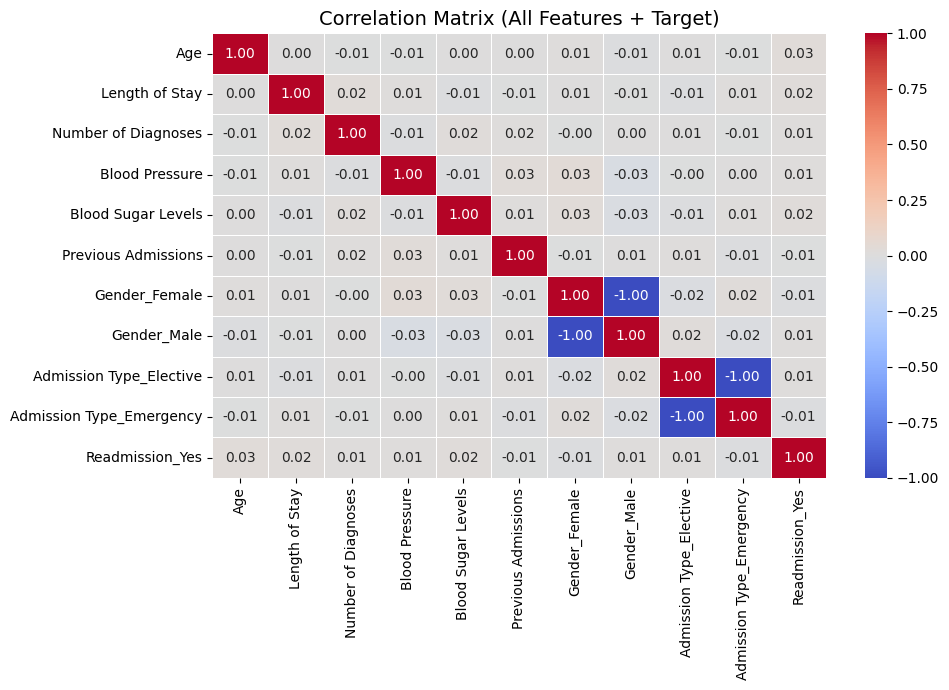

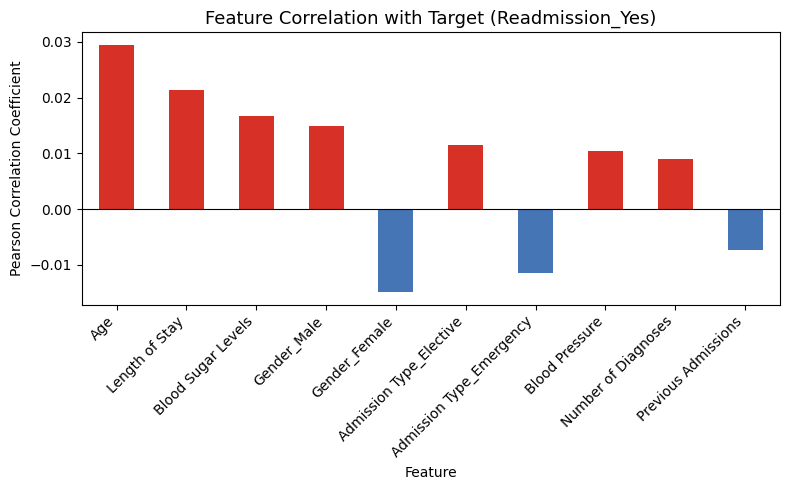

In [0]:
corr_data = X_all.copy()
corr_data['Readmission_Yes'] = y

corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (All Features + Target)', fontsize=14)
plt.tight_layout()
plt.show()

# Bar chart
target_corr = corr_matrix['Readmission_Yes'].drop('Readmission_Yes').sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
colors = ['#d73027' if v > 0 else '#4575b4' for v in target_corr]
target_corr.plot(kind='bar', color=colors)
plt.title('Feature Correlation with Target (Readmission_Yes)', fontsize=13)
plt.ylabel('Pearson Correlation Coefficient')
plt.xlabel('Feature')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Chi-Square Test (Categorical Features)

In [0]:
from sklearn.feature_selection import chi2

# Binary encoded categorical features
categorical_features = ['Gender_Female', 'Gender_Male',
                         'Admission Type_Elective', 'Admission Type_Emergency']

X_cat = X_all[categorical_features]
chi2_scores, p_values = chi2(X_cat, y)

chi2_results = pd.DataFrame({
    'Feature': categorical_features,
    'Chi2 Score': chi2_scores,
    'P-Value': p_values
}).sort_values('Chi2 Score', ascending=False)

print('Chi-Square Test Results:')
print(chi2_results.to_string(index=False))


Chi-Square Test Results:
                 Feature  Chi2 Score  P-Value
           Gender_Female    0.345390 0.556735
             Gender_Male    0.320957 0.571033
Admission Type_Emergency    0.206928 0.649186
 Admission Type_Elective    0.190247 0.662711


In [0]:
features =df_encoded.drop(columns= ['Readmission_Yes'])
y = df_encoded['Readmission_Yes']


In [0]:
#Instantiate the  standardScaler
scaler = StandardScaler()

#Fit the scaler to the data
scaler.fit(features)

#Transform the data by applying the scaling 
X = scaler.transform(features)

##Random Selection

#### Random Forest assigns an importance score to each feature based on how much it reduces impurity across all decision trees. This captures non-linear relationships that correlation analysis may miss.

Random Forest Feature Importances (ranked):
Blood Sugar Levels          0.206959
Blood Pressure              0.202961
Age                         0.184839
Length of Stay              0.163299
Number of Diagnoses         0.099129
Previous Admissions         0.076223
Gender_Female               0.017160
Admission Type_Emergency    0.016891
Admission Type_Elective     0.016365
Gender_Male                 0.016174


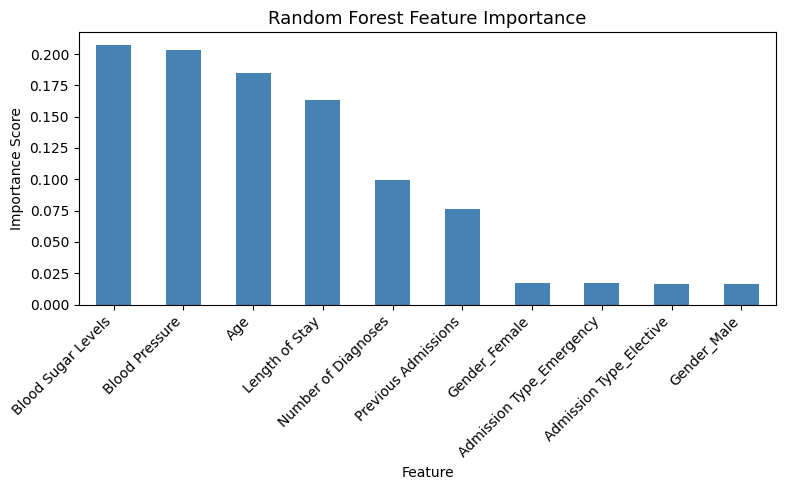

In [0]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest to get importance scores
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_all, y)

# Rank feature importances
feature_importances = pd.Series(rf_selector.feature_importances_, index=X_all.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print('Random Forest Feature Importances (ranked):')
print(feature_importances.to_string())

# Plot
plt.figure(figsize=(8, 5))
feature_importances.plot(kind='bar', color='steelblue')
plt.title('Random Forest Feature Importance', fontsize=13)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Based on feature selection Gender is dropped blood pressure level and blood sugar levels are retained absed on domain knowledge


##Final selected features

In [0]:
selected_features = [
    'Age',
    'Length of Stay',
    'Number of Diagnoses',
    'Blood Pressure',
    'Blood Sugar Levels',
    'Previous Admissions',
    'Admission Type_Elective',
    'Admission Type_Emergency'
]

X_selected = X_all[selected_features]
print('Final selected feature matrix shape:', X_selected.shape)
print('Selected features:', selected_features)

Final selected feature matrix shape: (3000, 8)
Selected features: ['Age', 'Length of Stay', 'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels', 'Previous Admissions', 'Admission Type_Elective', 'Admission Type_Emergency']


##Scale features and train-test split

In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Separate numerical and categorical selected features
numerical_cols = ['Age', 'Length of Stay', 'Number of Diagnoses',
                  'Blood Pressure', 'Blood Sugar Levels', 'Previous Admissions']
categorical_cols_selected = ['Admission Type_Elective', 'Admission Type_Emergency']

# Scale numerical columns only
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X_selected[numerical_cols])

# Combining scaled numericals with unchanged categoricals
X_final = np.concatenate([X_scaled_num, X_selected[categorical_cols_selected].values], axis=1)
final_feature_names = numerical_cols + categorical_cols_selected

print('Final scaled feature matrix shape:', X_final.shape)

# Train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Class balance in training set:')
print(pd.Series(y_train).value_counts())

Final scaled feature matrix shape: (3000, 8)
Training set: 2400 samples
Test set:     600 samples
Class balance in training set:
Readmission_Yes
0    1707
1     693
Name: count, dtype: int64


##Model Building 

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

### 3 MODELS/ALGORITHMS WILL BE USED NAMELY :LOGISTIC REGRSSION , DECSION TREE AND RANDOM FOREST 

####Model 1 :Logistic regression

In [0]:
# Logistic Regression is a linear model that calculates the 
# probability of a patient being readmitted (0 or 1).
# It is simple, fast, and easy to interpret.

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression - Training Complete")
print(f"Training Accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:     {lr_model.score(X_test, y_test):.4f}")

Logistic Regression - Training Complete
Training Accuracy: 0.7113
Test Accuracy:     0.7117


### Model 2: Decision Tree

In [0]:
# A Decision Tree splits the data into branches based on 
# feature thresholds, like a flowchart of yes/no questions.
# It is highly interpretable but prone to overfitting.

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree - Training Complete")
print(f"Training Accuracy: {dt_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:     {dt_model.score(X_test, y_test):.4f}")

Decision Tree - Training Complete
Training Accuracy: 1.0000
Test Accuracy:     0.5867


###Model 3 Random Forest

In [0]:
# Random Forest builds many Decision Trees and combines 
# their predictions. It is more accurate and less prone 
# to overfitting than a single Decision Tree.

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest - Training Complete")
print(f"Training Accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:     {rf_model.score(X_test, y_test):.4f}")

Random Forest - Training Complete
Training Accuracy: 1.0000
Test Accuracy:     0.7067


Logistic Regression → Stable but weak. Cannot capture complex patterns.
Decision Tree       → Powerful but dangerous. Memorises, does not learn.
Random Forest       → Best balance. Strong but needs tuning to reduce overfitting.

#The tuning step targets exactly this overfitting problem by testing combinations of:
ParameterPurposemax_depth: [None, 5, 10]  Limits how deep each tree can grow [ directly cuts ]

overfittingmin_samples_split: [2, 5, 10]Requires more patients at each split  [ prevents overly specific ]

branchesn_estimators: [50, 100, 200] Tests whether more trees improve generalisation

###GridSearchCV Tuning is a method in ML used to find the best combination of hyperparameters for a model 


In [0]:
###HYPERPARAMETER TUNING -GRIDSEARCH
####When training a model like decision tree there are settings you choose before training  these settingsa are called hyperparameters
####Gridsearch It means every possible combination of a set of hyperparameters is tried and the best combination is selected

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':      [50, 100, 200],   # number of trees
    'max_depth':         [None, 5, 10],    # how deep each tree can grow
    'min_samples_split': [2, 5, 10]        # min patients needed to split a node
}
# Total combinations tested: 3 x 3 x 3 = 27 combinations
# Each tested with 5-fold CV = 27 x 5 = 135 training runs

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,            # 5-fold cross validation
    scoring    = 'roc_auc',    # optimise for ROC-AUC (best for imbalanced data)
    n_jobs     = -1,           # use all CPU cores to run faster
    verbose    = 1             # print progress
)

grid_search.fit(X_train, y_train)

print()
print("=" * 50)
print("GRIDSEARCHCV RESULTS")
print("=" * 50)
print(f"Best Parameters:          {grid_search.best_params_}")
print(f"Best CV ROC-AUC Score:    {grid_search.best_score_:.4f}")
print("=" * 50)




Fitting 5 folds for each of 27 candidates, totalling 135 fits

GRIDSEARCHCV RESULTS
Best Parameters:          {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Best CV ROC-AUC Score:    0.5084


###### [1]From the results above we see  that   limiting each tree to a maximum of 10 levels gave the best results. The untuned Random Forest had [max_depth: None] meaning trees grew infinitely  that is what caused the 1.0000 training accuracy
#######[2] min_samples_split: 10 Each node needs at least 10 patients before it can be split further. The untuned model used 2, meaning it would split even when only 2 patients were present — creating extremely specific branches that memorise noise. Raising this to 10 forces the model to find more general patterns.
#######[3]n_estimators: 50 , 50 trees was found to be sufficient. More trees (100, 200) did not improve performance enough

######[4]ROC-AUC of 0.5 means the model basically random guessing  equivalent to flipping a coin to predict readmission. A score of 0.5084 is equivalent to 0.5. ---this is an important result because:

######All feature correlations were below 0.03 ;Chi-Square: all p-values above 0.55;Random Forest selector: top features only scored ~0.20 importance .The dataset appears to have very weak relationships between the available features and the readmission outcome


In [0]:

# TRAIN FINAL TUNED MODEL

# Extract the best model found by GridSearchCV
# and evaluate it on the test set

best_rf_model      = grid_search.best_estimator_
best_rf_pred       = best_rf_model.predict(X_test)
best_rf_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("TUNED RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Training Accuracy:  {best_rf_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:      {best_rf_model.score(X_test, y_test):.4f}")
print(f"Gap (Overfit Risk): {best_rf_model.score(X_train, y_train) - best_rf_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC Score:      {roc_auc_score(y_test, best_rf_pred_proba):.4f}")
print("=" * 50)

TUNED RANDOM FOREST RESULTS
Training Accuracy:  0.7492
Test Accuracy:      0.7117
Gap (Overfit Risk): 0.0375
ROC-AUC Score:      0.4924


In [0]:

# CROSS VALIDATION — OVERFITTING CHECK

##Splits training data into 5 parts
##Trains on 4, tests on 1, rotates 5 times
##Checks whether the model is consistent across different subsets of data

cv_scores = cross_val_score(
    best_rf_model, 
    X_train, y_train, 
    cv      = 5, 
    scoring = 'roc_auc'
)

print("=" * 50)
print("5-FOLD CROSS VALIDATION RESULTS")
print("=" * 50)
print(f"Score per fold:  {[round(s, 4) for s in cv_scores]}")
print(f"Mean ROC-AUC:    {cv_scores.mean():.4f}")
print(f"Std Deviation:   {cv_scores.std():.4f}")
print("=" * 50)
print()
if cv_scores.std() < 0.05:
    print("CONCLUSION: Low std deviation — model is stable and consistent")
    print("            No significant overfitting detected")
else:
    print("CONCLUSION: High std deviation — model performance varies")
    print("            Overfitting may still be present")

5-FOLD CROSS VALIDATION RESULTS
Score per fold:  [np.float64(0.5472), np.float64(0.5351), np.float64(0.4506), np.float64(0.5179), np.float64(0.4911)]
Mean ROC-AUC:    0.5084
Std Deviation:   0.0345

CONCLUSION: Low std deviation — model is stable and consistent
            No significant overfitting detected


In [0]:

# BEFORE vs AFTER TUNING COMPARISON

## Shows exactly what GridSearchCV improved

print("=" * 60)
print("         BEFORE vs AFTER TUNING COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'Before':>10} {'After':>10}")
print("-" * 60)
print(f"{'Training Accuracy':<30} {'1.0000':>10} {best_rf_model.score(X_train, y_train):>10.4f}")
print(f"{'Test Accuracy':<30} {'0.7067':>10} {best_rf_model.score(X_test, y_test):>10.4f}")
print(f"{'Gap (Overfit Risk)':<30} {'0.2933':>10} {best_rf_model.score(X_train, y_train) - best_rf_model.score(X_test, y_test):>10.4f}")
print(f"{'ROC-AUC':<30} {'N/A':>10} {roc_auc_score(y_test, best_rf_pred_proba):>10.4f}")
print("=" * 60)

         BEFORE vs AFTER TUNING COMPARISON
Metric                             Before      After
------------------------------------------------------------
Training Accuracy                  1.0000     0.7492
Test Accuracy                      0.7067     0.7117
Gap (Overfit Risk)                 0.2933     0.0375
ROC-AUC                               N/A     0.4924


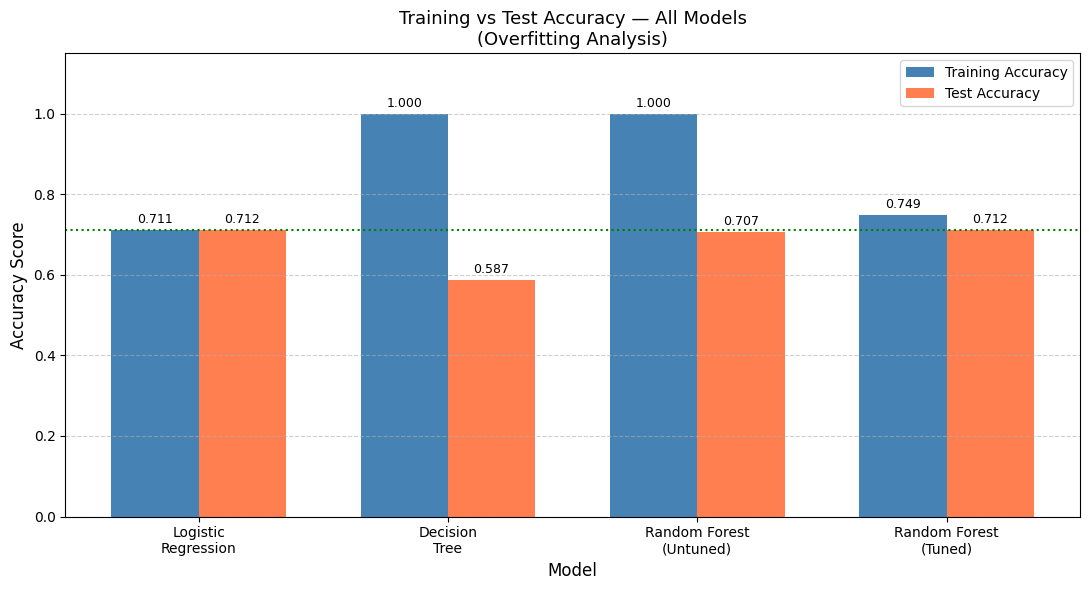

In [0]:

# VISUALISE BEFORE vs AFTER TUNING


models_comparison = ['Logistic\nRegression', 'Decision\nTree', 
                     'Random Forest\n(Untuned)', 'Random Forest\n(Tuned)']

train_scores = [
    lr_model.score(X_train, y_train),
    dt_model.score(X_train, y_train),
    rf_model.score(X_train, y_train),
    best_rf_model.score(X_train, y_train)
]

test_scores = [
    lr_model.score(X_test, y_test),
    dt_model.score(X_test, y_test),
    rf_model.score(X_test, y_test),
    best_rf_model.score(X_test, y_test)
]

x = np.arange(len(models_comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, train_scores, width, 
               label='Training Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_scores,  width, 
               label='Test Accuracy',     color='coral')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', 
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', 
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Training vs Test Accuracy — All Models\n(Overfitting Analysis)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models_comparison)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.axhline(y=0.7117, color='green', linestyle=':', linewidth=1.5, 
           label='Logistic Regression baseline')
plt.tight_layout()
plt.show()

###Model Comparison 


#### We used 5 metrics as the data set is mbalanced 71% not readmitted and 29% readmitted

In [0]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': (lr_pred, lr_pred_proba),
    'Decision Tree':       (dt_pred, dt_pred_proba),
    'Random Forest':       (rf_pred, rf_pred_proba)
}

comparison_results = []

for model_name, (pred, proba) in models.items():
    comparison_results.append({ 'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1 Score':  round(f1_score(y_test, pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 4)
    })

comparison_df = pd.DataFrame(comparison_results)
print("=" * 65)
print("           MODEL COMPARISON RESULTS")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)

           MODEL COMPARISON RESULTS
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7117     0.0000  0.0000    0.0000   0.4976
      Decision Tree    0.5867     0.2781  0.2717    0.2749   0.4930
      Random Forest    0.7067     0.4000  0.0347    0.0638   0.4942


/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



####Visualize model comparison 


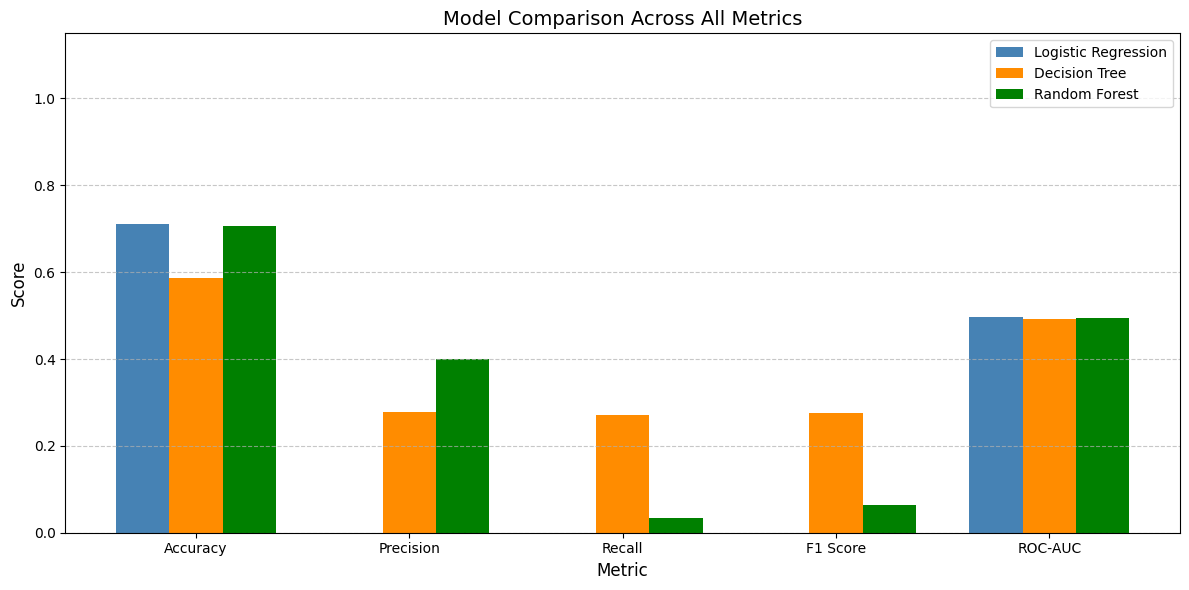

In [0]:
# Visualise model comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, 
       comparison_df[comparison_df['Model']=='Logistic Regression'][metrics].values[0], 
       width, label='Logistic Regression', color='steelblue')

ax.bar(x,         
       comparison_df[comparison_df['Model']=='Decision Tree'][metrics].values[0],       
       width, label='Decision Tree', color='darkorange')

ax.bar(x + width, 
       comparison_df[comparison_df['Model']=='Random Forest'][metrics].values[0],       
       width, label='Random Forest', color='green')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison Across All Metrics', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Model Evaluation

#### We evaluate the Tuned Random Forest using:
#### 1. Confusion Matrix        - breakdown of correct/incorrect predictions
#### 2. Classification Report   - Accuracy, Precision, Recall, F1 Score
#### 3. ROC-AUC Curve           - ability to distinguish between classes
#### 4. Overfitting Discussion  - training vs test performance summary

In [0]:

print("Starting Model Evaluation — Tuned Random Forest")
print(f"Test set size: {X_test.shape[0]} patients")

Starting Model Evaluation — Tuned Random Forest
Test set size: 600 patients


##Confusion Matrix:
####What the model predicted vs What the actual answer was

|                     | **Predicted Positive** | **Predicted Negative** |
| ------------------- | ---------------------- | ---------------------- |
| **Actual Positive** | True Positive (TP)     | False Negative (FN)    |
| **Actual Negative** | False Positive (FP)    | True Negative (TN)     |


True Positive (TP) is when model says YES but actual answer is YES which is correct
True Negative (TN) is when model says NO and Actual answer is  which is correct
False  Negative (FN) is when model says NO and Actual answer is YES  whisch is wrong
False Positive (FP) is when model says YES and Actual answer is NO which is wrong 

BREAKS DOWN CORRECT AND INCORRECT PREDICTIONS



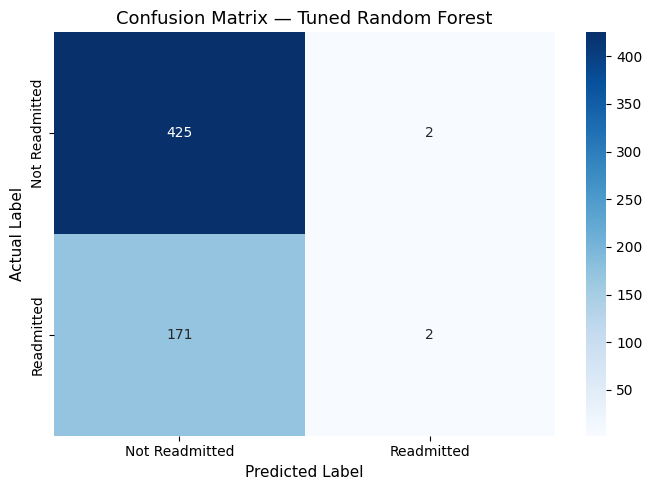

CONFUSION MATRIX BREAKDOWN
True Negatives  (TN): 425  — correctly predicted NOT readmitted
False Positives (FP): 2  — predicted readmitted but were NOT
False Negatives (FN): 171  — missed actual readmissions
True Positives  (TP): 2  — correctly predicted readmitted
Total Correct:   427 out of 600
Total Incorrect: 173 out of 600


In [0]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_rf_pred)
TN, FP, FN, TP = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix — Tuned Random Forest', fontsize=13)
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

print("=" * 50)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 50)
print(f"True Negatives  (TN): {TN}  — correctly predicted NOT readmitted")
print(f"False Positives (FP): {FP}  — predicted readmitted but were NOT")
print(f"False Negatives (FN): {FN}  — missed actual readmissions")
print(f"True Positives  (TP): {TP}  — correctly predicted readmitted")
print("=" * 50)
print(f"Total Correct:   {TN + TP} out of {TN + FP + FN + TP}")
print(f"Total Incorrect: {FP + FN} out of {TN + FP + FN + TP}")

###CLASSIFICATION REPORT:
A classification report is basically a summary of how well your model performed, using several key metrics all derived from your confusion matrix.

#### 1) Precision : When the model predicts a class, how often is it correct?
  =>   Precision = TP / (TP + FP)

#### 2) Recall : Out of all actual cases, how many did the model catch

  => Recall = TP / (TP + FN)

#### 3) F1-Score  : Balance between precision and recall

   => F1 = 2 × (Precision × Recall) / (Precision + Recall)
  
  Useful when data is imbalanced

#### 4) Support : Number of actual samples in each class

Class 0 (Not readmitted)
Class 1 (Readmitted)




In [0]:
from sklearn.metrics import (classification_report, accuracy_score,
                              precision_score, recall_score, 
                              f1_score, roc_auc_score)

print("=" * 55)
print("   CLASSIFICATION REPORT — Tuned Random Forest")
print("=" * 55)
print(classification_report(y_test, best_rf_pred,
      target_names=['Not Readmitted', 'Readmitted']))

print("=" * 55)
print("INDIVIDUAL METRIC SCORES")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_test, best_rf_pred):.4f}  — overall correct predictions")
print(f"Precision: {precision_score(y_test, best_rf_pred):.4f}  — correctness of readmission alerts")
print(f"Recall:    {recall_score(y_test, best_rf_pred):.4f}  — readmitted patients actually caught")
print(f"F1 Score:  {f1_score(y_test, best_rf_pred):.4f}  — balance of precision and recall")
print(f"ROC-AUC:   {roc_auc_score(y_test, best_rf_pred_proba):.4f}  — overall discrimination ability")
print("=" * 55)

   CLASSIFICATION REPORT — Tuned Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.71      1.00      0.83       427
    Readmitted       0.50      0.01      0.02       173

      accuracy                           0.71       600
     macro avg       0.61      0.50      0.43       600
  weighted avg       0.65      0.71      0.60       600

INDIVIDUAL METRIC SCORES
Accuracy:  0.7117  — overall correct predictions
Precision: 0.5000  — correctness of readmission alerts
Recall:    0.0116  — readmitted patients actually caught
F1 Score:  0.0226  — balance of precision and recall
ROC-AUC:   0.4924  — overall discrimination ability


###ROC-AUC CURVE 
ROC = Receiver Operating Characteristic
This graph tshows:

How well our  model separates the two classes ( readmitted vs not readmitted)

####X-axis → False Positive Rate (FPR)
FPR = FP / (FP + TN)
#### Y-axis → True Positive Rate (TPR) (same as Recall)
TPR = TP / (TP + FN)


###AUC = Area Under the Curve

summarizes the ROC curve into one number:

1.0 → perfect
0.8+ → good
0.7 → okay
0.5 → random
< 0.5 → worse than random

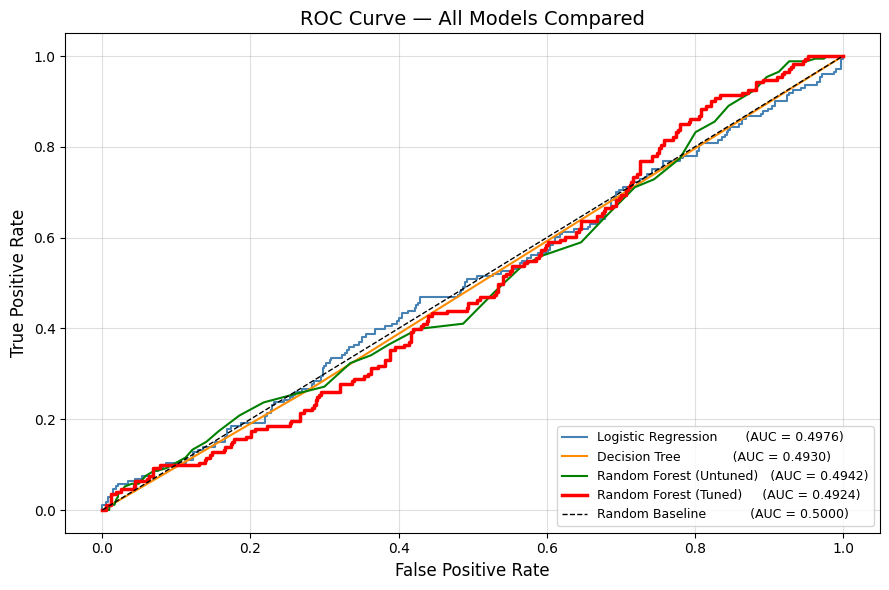

ROC-AUC SCORES RANKED
Logistic Regression            0.4976
Random Forest (Untuned)        0.4942
Decision Tree                  0.4930
Random Forest (Tuned)          0.4924


In [0]:
from sklearn.metrics import roc_curve, auc

# Get ROC curve data for all models
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, lr_pred_proba)
fpr_dt,   tpr_dt,   _ = roc_curve(y_test, dt_pred_proba)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, rf_pred_proba)
fpr_best, tpr_best, _ = roc_curve(y_test, best_rf_pred_proba)

auc_lr   = auc(fpr_lr,   tpr_lr)
auc_dt   = auc(fpr_dt,   tpr_dt)
auc_rf   = auc(fpr_rf,   tpr_rf)
auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(9, 6))
plt.plot(fpr_lr,   tpr_lr,
         label=f'Logistic Regression       (AUC = {auc_lr:.4f})', 
         color='steelblue', linewidth=1.5)
plt.plot(fpr_dt,   tpr_dt,   
         label=f'Decision Tree             (AUC = {auc_dt:.4f})', 
         color='darkorange', linewidth=1.5)
plt.plot(fpr_rf,   tpr_rf,   
         label=f'Random Forest (Untuned)   (AUC = {auc_rf:.4f})', 
         color='green', linewidth=1.5)
plt.plot(fpr_best, tpr_best, 
         label=f'Random Forest (Tuned)     (AUC = {auc_best:.4f})', 
         color='red', linewidth=2.5)
plt.plot([0, 1], [0, 1], 
         'k--', label='Random Baseline           (AUC = 0.5000)', 
         linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models Compared', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("=" * 50)
print("ROC-AUC SCORES RANKED")
print("=" * 50)
roc_results = {
    'Logistic Regression':      auc_lr,
    'Decision Tree':            auc_dt,
    'Random Forest (Untuned)':  auc_rf,
    'Random Forest (Tuned)':    auc_best
}
for model, score in sorted(roc_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<30} {score:.4f}")
print("=" * 50)

EVERYTHING IS FAILING EQUALLY THEREFORE WE CAN SAY THE PROBLEM IS NOT THE MODEL BUT THE DATA ; THERE ARE NO VISIBLE PATTERNS IN THE DATA 

###Overfitting discussion
Here we nalyze whether our model is generalizing well or just memorizing the training data 

In [0]:


print("=" * 65)
print("              OVERFITTING ANALYSIS — ALL MODELS")
print("=" * 65)
print(f"{'Model':<30} {'Train':>8} {'Test':>8} {'Gap':>8} {'Status':>15}")
print("-" * 65)

models_eval = [
    ('Logistic Regression',     lr_model,       'Low'),
    ('Decision Tree',           dt_model,       'Severe'),
    ('Random Forest (Untuned)', rf_model,       'High'),
    ('Random Forest (Tuned)',   best_rf_model,  'Minimal'),
]

for name, model, status in models_eval:
    train = model.score(X_train, y_train)
    test  = model.score(X_test,  y_test)
    gap   = train - test
    print(f"{name:<30} {train:>8.4f} {test:>8.4f} {gap:>8.4f} {status:>15}")

print("=" * 65)
print()
print("Overfitting Thresholds:")
print("  Gap < 0.05          Low risk   — model generalises well")
print("  Gap 0.05 to 0.15    Moderate   — monitor carefully")
print("  Gap > 0.15          High risk  — regularisation needed")

              OVERFITTING ANALYSIS — ALL MODELS
Model                             Train     Test      Gap          Status
-----------------------------------------------------------------
Logistic Regression              0.7113   0.7117  -0.0004             Low
Decision Tree                    1.0000   0.5867   0.4133          Severe
Random Forest (Untuned)          1.0000   0.7067   0.2933            High
Random Forest (Tuned)            0.7492   0.7117   0.0375         Minimal

Overfitting Thresholds:
  Gap < 0.05          Low risk   — model generalises well
  Gap 0.05 to 0.15    Moderate   — monitor carefully
  Gap > 0.15          High risk  — regularisation needed


In [0]:

# FINAL EVALUATION SUMMARY


print("=" * 55)
print("        FINAL MODEL EVALUATION SUMMARY")
print("        Selected Model: Tuned Random Forest")
print("=" * 55)
print(f"  Accuracy:         {accuracy_score(y_test, best_rf_pred):.4f}")
print(f"  Precision:        {precision_score(y_test, best_rf_pred):.4f}")
print(f"  Recall:           {recall_score(y_test, best_rf_pred):.4f}")
print(f"  F1 Score:         {f1_score(y_test, best_rf_pred):.4f}")
print(f"  ROC-AUC:          {roc_auc_score(y_test, best_rf_pred_proba):.4f}")
print(f"  CV Mean ROC-AUC:  {cv_scores.mean():.4f}")
print(f"  CV Std Deviation: {cv_scores.std():.4f}")
print("=" * 55)
print()
print("Overfitting Mitigation Strategies Applied:")
print("  1. max_depth=10        — limited tree growth depth")
print("  2. min_samples_split=10 — prevented overly specific splits")
print("  3. 5-fold cross validation — verified stability across subsets")
print("  4. stratify=y split    — preserved class balance in evaluation")
print("=" * 55)

        FINAL MODEL EVALUATION SUMMARY
        Selected Model: Tuned Random Forest
  Accuracy:         0.7117
  Precision:        0.5000
  Recall:           0.0116
  F1 Score:         0.0226
  ROC-AUC:          0.4924
  CV Mean ROC-AUC:  0.5084
  CV Std Deviation: 0.0345

Overfitting Mitigation Strategies Applied:
  1. max_depth=10        — limited tree growth depth
  2. min_samples_split=10 — prevented overly specific splits
  3. 5-fold cross validation — verified stability across subsets
  4. stratify=y split    — preserved class balance in evaluation
